# Part I - General Characteristics

### Q1+Q2

In [1]:
# Part I (Q1–Q2): Cosmology for GN20 at z=4.05
# Adopted cosmology: Ωm = 0.3, ΩΛ = 0.7, H0 = 70 km/s/Mpc (flat ΛCDM)
# (Assignment instruction: use an online cosmology calculator or astropy.cosmology)  [gn20_project_AP(.pdf), Part I] 

import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

# Given
z = 4.05
H0 = 70 * (u.km / u.s / u.Mpc)
Om0 = 0.3
Ode0 = 0.7  # implied by flatness; FlatLambdaCDM uses Om0 and H0, with Ode0 = 1-Om0

cosmo = FlatLambdaCDM(H0=H0, Om0=Om0, Tcmb0=2.725*u.K)  # Tcmb0 default ok; doesn't affect basic distances/times much here

# --- Definitions (standard cosmology) ---
# Lookback time:
#   t_L(z) = ∫_0^z dz' / [(1+z') H(z')]
#
# Age of the Universe at redshift z:
#   t(z) = t0 - t_L(z)
#
# Luminosity distance:
#   D_L(z) = (1+z) * D_M(z)
# where D_M is the transverse comoving distance (for flat cosmology, D_M = D_C).

# --- Numerical evaluation with astropy ---
t_lookback = cosmo.lookback_time(z)   # t_L(z)
t_age = cosmo.age(z)                 # t(z) directly
D_L = cosmo.luminosity_distance(z)   # D_L(z)

print(f"z = {z}")
print(f"Lookback time t_L(z) = {t_lookback.to(u.Gyr):.3f}")
print(f"Age of Universe t(z)  = {t_age.to(u.Gyr):.3f}")
print(f"Luminosity distance D_L(z) = {D_L.to(u.Mpc):.3e}")

z = 4.05
Lookback time t_L(z) = 11.971 Gyr
Age of Universe t(z)  = 1.491 Gyr
Luminosity distance D_L(z) = 3.637e+04 Mpc


### Q3+Q4

In [3]:
# Part I (Q3–Q4): Compare GN20 to the Milky Way, and doubling time / mass growth
# GN20 numbers from the project statement: SFR ≈ 3000 Msun/yr, M* = 4×10^11 Msun  [Part I] :contentReference[oaicite:1]{index=1}

import astropy.units as u

# --- Given for GN20 (from assignment) ---
SFR_gn20 = 3000 * (u.Msun / u.yr)
Mstar_gn20 = 4e11 * u.Msun

# --- Reference values for the Milky Way (typical literature values; adjust if you prefer) ---
SFR_mw = 1.9 * (u.Msun / u.yr)     # Kennicutt & Evans (2012)
Mstar_mw = 8.25e10 * u.Msun           # Kennicutt & Evans (2012)

# -------------------------
# Q3) Ratios relative to MW
# -------------------------
# Formulas:
#   R_SFR = SFR_GN20 / SFR_MW
#   R_M*  = M*_GN20 / M*_MW

R_sfr = (SFR_gn20 / SFR_mw).decompose()
R_mstar = (Mstar_gn20 / Mstar_mw).decompose()

print("Q3) Comparison to Milky Way")
print(f"  SFR ratio  (GN20 / MW) = {R_sfr:.2e}")
print(f"  M* ratio   (GN20 / MW) = {R_mstar:.2f}")

# -----------------------------------
# Q4) Doubling time + 'mass today'
# -----------------------------------
# Formulas (simple constant-SFR toy model, ignoring stellar mass loss):
#   t_double = M* / SFR
#   M*_today ≈ M*(z) + SFR × Δt
# where Δt is the time elapsed from z to today, i.e. lookback time t_L(z).
#
# We'll use Δt = t_lookback computed in Q1–Q2.

t_double = (Mstar_gn20 / SFR_gn20).to(u.yr)
delta_t = t_lookback.to(u.yr)   # from the earlier cosmology cell (Q1–Q2)

Mstar_today = (Mstar_gn20 + SFR_gn20 * delta_t).to(u.Msun)

print("\nQ4) Growth at constant SFR")
print(f"  Doubling time t_double = {t_double.to(u.Myr):.2f}")
print(f"  Lookback time Δt       = {delta_t.to(u.Gyr):.2f}")
print(f"  M*_today (toy model)   = {Mstar_today:.3e}")

Q3) Comparison to Milky Way
  SFR ratio  (GN20 / MW) = 1.58e+03
  M* ratio   (GN20 / MW) = 4.85

Q4) Growth at constant SFR
  Doubling time t_double = 133.33 Myr
  Lookback time Δt       = 11.97 Gyr
  M*_today (toy model)   = 3.631e+13 solMass


# Part II - Spectroscopy and derivation of Observables

### Q1 — Expected observed frequency / wavelength of CO(1–0)

In [4]:
# Q1: expected observing frequency for CO(1-0)

import numpy as np

z = 4.05
nu_rest_GHz = 115.3      # GHz
lam0_mm = 2.6            # mm

nu_obs_GHz = nu_rest_GHz / (1 + z)
lam_obs_mm = lam0_mm * (1 + z)

print(f"Expected nu_obs = {nu_obs_GHz:.5f} GHz")
print(f"Expected lambda_obs = {lam_obs_mm:.3f} mm  = {lam_obs_mm/10:.3f} cm")

Expected nu_obs = 22.83168 GHz
Expected lambda_obs = 13.130 mm  = 1.313 cm


### Task — Load spectrum, plot, fit Gaussian in frequency space

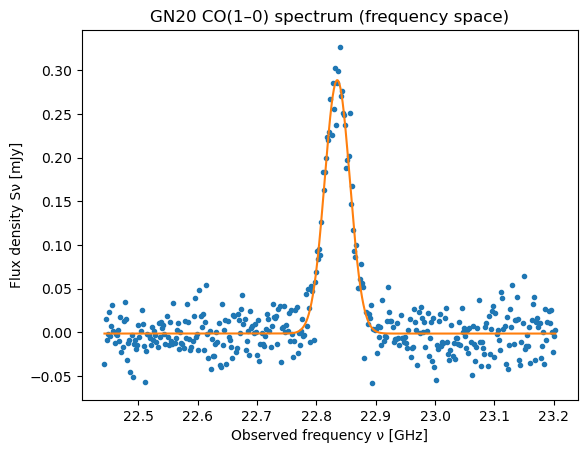

Gaussian fit (frequency space):
  Line center nu0 = 22.835283 ± 0.000494 GHz
  Sigma (freq)    = 0.021158 ± 0.000508 GHz
  Peak A          = 0.2900 ± 0.0059 mJy
  Baseline C      = -0.0014 ± 0.0012 mJy


In [12]:
# Load and plot the spectrum + Gaussian fit in frequency space

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

spec = np.loadtxt("../W9-The cold interstellar medium of galaxies/gn20spec_freq.txt")
nu = spec[:, 0]          # GHz
S_mJy = spec[:, 1]       # mJy

def gauss(nu, A, nu0, sigma, C):
    return A * np.exp(-(nu - nu0)**2 / (2 * sigma**2)) + C

# initial guesses
C0 = np.median(S_mJy)
A0 = S_mJy.max() - C0
nu0_guess = nu[np.argmax(S_mJy)]
sigma0 = 0.02  # GHz (rough)

p0 = [A0, nu0_guess, sigma0, C0]
bounds = ([-np.inf, nu.min(), 0, -np.inf], [np.inf, nu.max(), np.inf, np.inf])

popt, pcov = curve_fit(gauss, nu, S_mJy, p0=p0, bounds=bounds, maxfev=20000)
perr = np.sqrt(np.diag(pcov))

A_fit, nu0_fit, sigma_nu_fit, C_fit = popt

# plot
nu_plot = np.linspace(nu.min(), nu.max(), 2000)
plt.figure()
plt.plot(nu, S_mJy, marker=".", linestyle="none")
plt.plot(nu_plot, gauss(nu_plot, *popt))
plt.xlabel("Observed frequency ν [GHz]")
plt.ylabel("Flux density Sν [mJy]")
plt.title("GN20 CO(1–0) spectrum (frequency space)")
plt.show()

print("Gaussian fit (frequency space):")
print(f"  Line center nu0 = {nu0_fit:.6f} ± {perr[1]:.6f} GHz")
print(f"  Sigma (freq)    = {sigma_nu_fit:.6f} ± {perr[2]:.6f} GHz")
print(f"  Peak A          = {A_fit:.4f} ± {perr[0]:.4f} mJy")
print(f"  Baseline C      = {C_fit:.4f} ± {perr[3]:.4f} mJy")

### Q2 — Central frequency and inferred redshift

In [13]:
# Q2: redshift from fitted line center

z_fit = (nu_rest_GHz / nu0_fit) - 1
print(f"Measured central frequency: nu0 = {nu0_fit:.6f} GHz")
print(f"Inferred redshift: z = {z_fit:.6f}")

Measured central frequency: nu0 = 22.835283 GHz
Inferred redshift: z = 4.049204


### Task - Convert frequency → velocity and fit Gaussian in velocity space

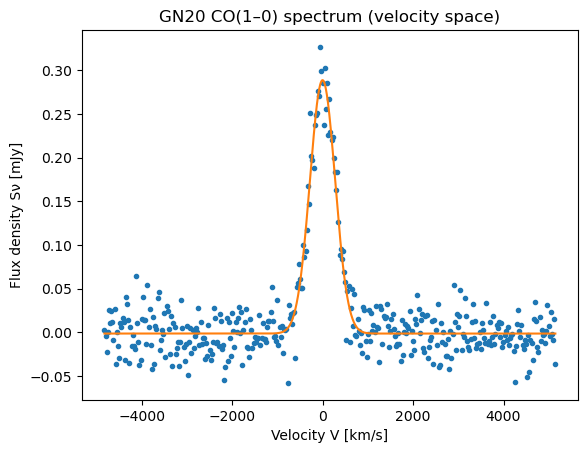

Gaussian fit (velocity space):
  Center V0  = -0.000 ± 6.487 km/s
  Sigma σ    = 277.772 ± 6.671 km/s
  Peak A     = 0.2900 ± 0.0059 mJy
  Baseline C = -0.0014 ± 0.0012 mJy
  Integrated flux I_CO = 0.201902 Jy km/s


In [14]:
# Frequency -> velocity using Eq. (1) from the assignment:
# V = c * (nu0 - nu)/nu0   (Eq. 1)  :contentReference[oaicite:4]{index=4}

c_kms = 299792.458  # km/s
V = c_kms * (nu0_fit - nu) / nu0_fit

def gauss_v(V, A, V0, sigma, C):
    return A * np.exp(-(V - V0)**2 / (2 * sigma**2)) + C

# initial guesses
C0 = np.median(S_mJy)
A0 = S_mJy.max() - C0
V0_guess = V[np.argmax(S_mJy)]
sigma0 = 250.0  # km/s

p0 = [A0, V0_guess, sigma0, C0]
bounds = ([-np.inf, V.min(), 0, -np.inf], [np.inf, V.max(), np.inf, np.inf])

popt_v, pcov_v = curve_fit(gauss_v, V, S_mJy, p0=p0, bounds=bounds, maxfev=20000)
perr_v = np.sqrt(np.diag(pcov_v))

A_v, V0_v, sigma_v, C_v = popt_v

# plot
V_plot = np.linspace(V.min(), V.max(), 2000)
plt.figure()
plt.plot(V, S_mJy, marker=".", linestyle="none")
plt.plot(V_plot, gauss_v(V_plot, *popt_v))
plt.xlabel("Velocity V [km/s]")
plt.ylabel("Flux density Sν [mJy]")
plt.title("GN20 CO(1–0) spectrum (velocity space)")
plt.show()

print("Gaussian fit (velocity space):")
print(f"  Center V0  = {V0_v:.3f} ± {perr_v[1]:.3f} km/s")
print(f"  Sigma σ    = {sigma_v:.3f} ± {perr_v[2]:.3f} km/s")
print(f"  Peak A     = {A_v:.4f} ± {perr_v[0]:.4f} mJy")
print(f"  Baseline C = {C_v:.4f} ± {perr_v[3]:.4f} mJy")

# Integrated line flux (baseline-subtracted Gaussian):
# I_CO = ∫ Sν dV = A * σ * sqrt(2π)    (mJy km/s)  -> convert to Jy km/s
I_mJy_kms = A_v * sigma_v * np.sqrt(2*np.pi)
I_Jy_kms = I_mJy_kms / 1000.0

print(f"  Integrated flux I_CO = {I_Jy_kms:.6f} Jy km/s")

### Q4 — FWHM of the line

In [15]:
# Q4: FWHM from sigma
FWHM = 2*np.sqrt(2*np.log(2)) * sigma_v
print(f"FWHM = {FWHM:.2f} km/s")

FWHM = 654.10 km/s


### Q5 — CO line luminosity 𝐿CO


In [16]:
# Q5: compute D_L with a numerical integral (flat ΛCDM) + compute L'_CO using Eq. (5)

from scipy.integrate import quad

Om = 0.3
Ol = 0.7
H0 = 70.0  # km/s/Mpc

def E(z):
    return np.sqrt(Om*(1+z)**3 + Ol)

def comoving_distance_Mpc(z):
    integral, _ = quad(lambda zp: 1.0/E(zp), 0, z, limit=2000)
    return (c_kms/H0) * integral

def luminosity_distance_Mpc(z):
    Dc = comoving_distance_Mpc(z)
    return (1+z) * Dc  # flat cosmology

DL_Mpc = luminosity_distance_Mpc(z_fit)

Lprime = 3.25e7 * I_Jy_kms * (nu0_fit**-2) * (DL_Mpc**2) * ((1+z_fit)**-3)

print(f"D_L = {DL_Mpc:.2f} Mpc")
print(f"L'_CO = {Lprime:.3e} K km/s pc^2")

D_L = 36375.56 Mpc
L'_CO = 1.293e+11 K km/s pc^2


# Part III - The molecular gas reservoir

In [17]:
import numpy as np

# Given in the assignment
Mstar = 4e11         # Msun
SFR = 3000.0         # Msun/yr
alpha_starburst = 0.8
alpha_normal = 4.5
delta_gd = 100.0     # Mgas/Mdust ~ 100
Mtot_Reff = 3.0e11   # Msun (within Reff)

# You should already have Lprime from Part II Q5:
# Lprime in units of K km/s pc^2
print(f"L'_CO = {Lprime:.3e} K km/s pc^2")

L'_CO = 1.293e+11 K km/s pc^2


### Q1 — Mgas for αCO = 0.8 and 4.5

In [18]:
# Q1: Gas mass for two extreme alpha_CO values
# Eq. (6): M_H2 = alpha_CO * L'_CO  :contentReference[oaicite:4]{index=4}
# Eq. (8): M_gas ≈ M_H2            :contentReference[oaicite:5]{index=5}

Mgas_08 = alpha_starburst * Lprime
Mgas_45 = alpha_normal * Lprime

print("Q1) Gas masses:")
print(f"  alpha_CO = 0.8 : Mgas ≈ {Mgas_08:.3e} Msun")
print(f"  alpha_CO = 4.5 : Mgas ≈ {Mgas_45:.3e} Msun")

Q1) Gas masses:
  alpha_CO = 0.8 : Mgas ≈ 1.035e+11 Msun
  alpha_CO = 4.5 : Mgas ≈ 5.821e+11 Msun


### Q2 — Total baryonic mass Mbar for both cases

In [19]:
# Q2: Total baryonic mass using Eq. (7) and delta_gd ~ 100
# Eq. (7): Mbar = Mstars + Mgas + Mdust  :contentReference[oaicite:8]{index=8}
# Mdust = Mgas/delta_gd

def Mbar_total(Mgas):
    Mdust = Mgas / delta_gd
    return Mstar + Mgas + Mdust

Mbar_08 = Mbar_total(Mgas_08)
Mbar_45 = Mbar_total(Mgas_45)

print("Q2) Total baryonic mass (whole galaxy):")
print(f"  alpha_CO = 0.8 : Mbar ≈ {Mbar_08:.3e} Msun")
print(f"  alpha_CO = 4.5 : Mbar ≈ {Mbar_45:.3e} Msun")

Q2) Total baryonic mass (whole galaxy):
  alpha_CO = 0.8 : Mbar ≈ 5.045e+11 Msun
  alpha_CO = 4.5 : Mbar ≈ 9.879e+11 Msun


### Q3 — Maximum physically acceptable αCO from the dynamical mass within Reff

In [20]:
# Q3: Maximum alpha_CO such that baryons within Reff do not exceed Mtot(Reff)

f = 0.5  # fraction inside Reff for stars/gas/dust (given by statement)
factor_dust = (1 + 1/delta_gd)

# Condition: f*Mstar + f*(alpha*Lprime)*factor_dust <= Mtot_Reff
alpha_max = (Mtot_Reff - f*Mstar) / (f*Lprime*factor_dust)

print("Q3) Maximum physically acceptable alpha_CO:")
print(f"  alpha_CO,max ≈ {alpha_max:.3f}")

Q3) Maximum physically acceptable alpha_CO:
  alpha_CO,max ≈ 1.531


### Q4 — For αCO = 0.8 compare Mbar to Mtot within Reff, and explain discrepancy

In [21]:
# Q4: Compare Mbar(Reff) to Mtot(Reff) for alpha_CO=0.8

def Mbar_within_Reff(Mgas):
    Mdust = Mgas / delta_gd
    return f*Mstar + f*Mgas + f*Mdust

MbarReff_08 = Mbar_within_Reff(Mgas_08)

print("Q4) Within Reff (alpha_CO=0.8):")
print(f"  Mbar(<Reff) ≈ {MbarReff_08:.3e} Msun")
print(f"  Mtot(<Reff) = {Mtot_Reff:.3e} Msun")
print(f"  Difference (Mtot - Mbar) ≈ {(Mtot_Reff - MbarReff_08):.3e} Msun")

Q4) Within Reff (alpha_CO=0.8):
  Mbar(<Reff) ≈ 2.523e+11 Msun
  Mtot(<Reff) = 3.000e+11 Msun
  Difference (Mtot - Mbar) ≈ 4.774e+10 Msun


### Q5 — Depletion time for αCO = 0.8

In [22]:
# Q5: SFE and depletion time for alpha_CO = 0.8

MH2_08 = Mgas_08  # Eq. (8): Mgas ≈ MH2 :contentReference[oaicite:12]{index=12}

SFE_per_yr = SFR / MH2_08
SFE_per_Gyr = SFE_per_yr * 1e9
tdep_yr = MH2_08 / SFR
tdep_Myr = tdep_yr / 1e6

print("Q5) Star formation efficiency and depletion time (alpha_CO=0.8):")
print(f"  SFE = {SFE_per_Gyr:.2f} 1/Gyr")
print(f"  tau_dep = {tdep_Myr:.2f} Myr  (= {tdep_yr/1e9:.4f} Gyr)")

Q5) Star formation efficiency and depletion time (alpha_CO=0.8):
  SFE = 28.99 1/Gyr
  tau_dep = 34.49 Myr  (= 0.0345 Gyr)


# Part IV - Far-Infrared Emission

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -----------------------------
# Given from earlier parts
# -----------------------------
z = 4.05
DL_Mpc = 36375.56  # your computed luminosity distance

# -----------------------------
# Load photometry file
# Columns: lambda_obs [um], S_nu [mJy], sigma_S [mJy]
# -----------------------------
phot = np.loadtxt("../W9-The cold interstellar medium of galaxies/gn20phot.txt")
lam_obs_um = phot[:, 0]
S_mJy = phot[:, 1]
Serr_mJy = phot[:, 2]

# -----------------------------
# Physical constants (cgs) (as in statement)
# -----------------------------
c = 2.99792458e10      # cm/s
h = 6.62607004e-27     # erg*s
kB = 1.38064852e-16    # erg/K

Mpc_to_cm = 3.085677581e24
DL_cm = DL_Mpc * Mpc_to_cm

print(f"Loaded {len(lam_obs_um)} photometry points.")

Loaded 9 photometry points.


### Task — plot observed SED: S(νobs) vs λobs and vs νobs

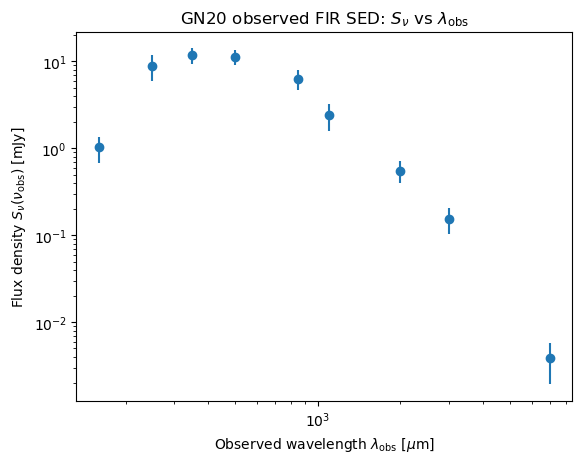

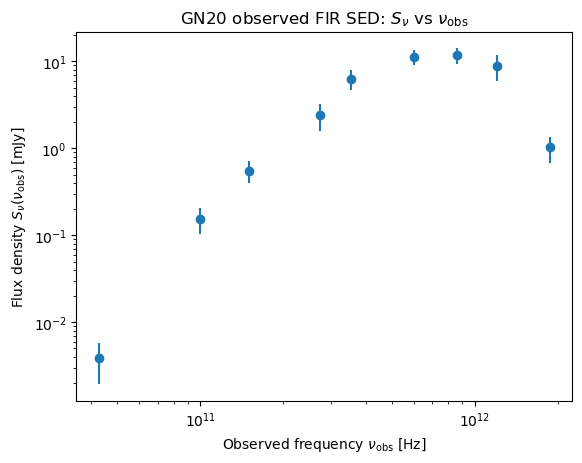

In [24]:
# Convert lambda_obs -> nu_obs
lam_obs_cm = lam_obs_um * 1e-4
nu_obs = c / lam_obs_cm  # Hz

# Plot S_nu vs lambda_obs (log-log)
plt.figure()
plt.errorbar(lam_obs_um, S_mJy, yerr=Serr_mJy, fmt='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Observed wavelength $\lambda_{\rm obs}$ [$\mu$m]")
plt.ylabel(r"Flux density $S_\nu(\nu_{\rm obs})$ [mJy]")
plt.title("GN20 observed FIR SED: $S_\\nu$ vs $\\lambda_{\\rm obs}$")
plt.show()

# Plot S_nu vs nu_obs (log-log)
plt.figure()
plt.errorbar(nu_obs, S_mJy, yerr=Serr_mJy, fmt='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Observed frequency $\nu_{\rm obs}$ [Hz]")
plt.ylabel(r"Flux density $S_\nu(\nu_{\rm obs})$ [mJy]")
plt.title("GN20 observed FIR SED: $S_\\nu$ vs $\\nu_{\\rm obs}$")
plt.show()

### Task - Convert observed flux densities → rest-frame luminosities (Eq. 10)

Example: lambda_obs=160.0 um -> lambda_rest=31.68 um
Example Lnu_rest[0] = 3.209e+32 erg/s/Hz


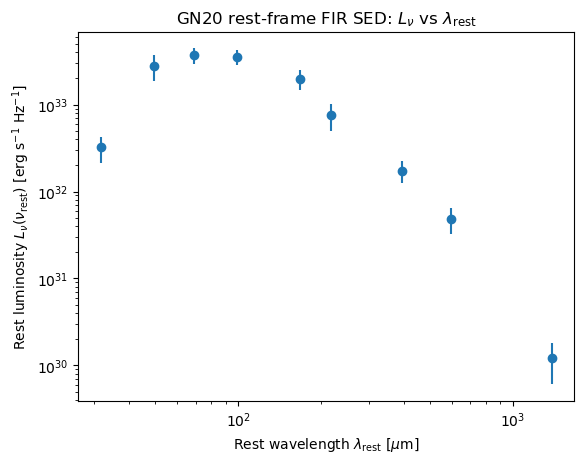

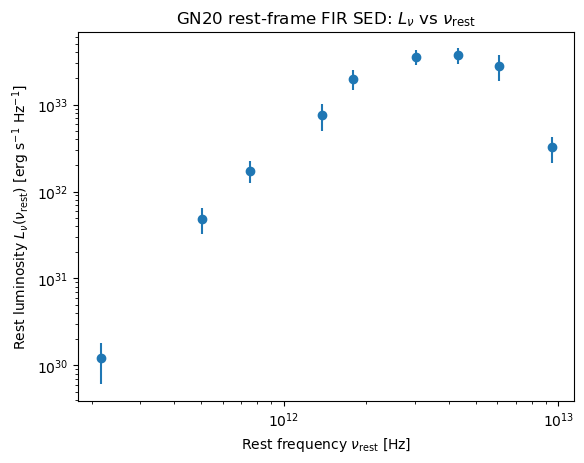

In [25]:
# Convert mJy -> cgs flux density
S_cgs = S_mJy * 1e-26
Serr_cgs = Serr_mJy * 1e-26

# Eq. (10): L_nu(rest) = 4π D_L^2 / (1+z) * S_nu(obs)
Lnu_rest = 4*np.pi * DL_cm**2 / (1+z) * S_cgs
Lnu_err  = 4*np.pi * DL_cm**2 / (1+z) * Serr_cgs

# Rest-frame frequency and wavelength (Eq. 11)
nu_rest = nu_obs * (1+z)
lam_rest_um = lam_obs_um / (1+z)

print(f"Example: lambda_obs={lam_obs_um[0]:.1f} um -> lambda_rest={lam_rest_um[0]:.2f} um")
print(f"Example Lnu_rest[0] = {Lnu_rest[0]:.3e} erg/s/Hz")

# Lnu vs lambda_rest
plt.figure()
plt.errorbar(lam_rest_um, Lnu_rest, yerr=Lnu_err, fmt='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Rest wavelength $\lambda_{\rm rest}$ [$\mu$m]")
plt.ylabel(r"Rest luminosity $L_\nu(\nu_{\rm rest})$ [erg s$^{-1}$ Hz$^{-1}$]")
plt.title("GN20 rest-frame FIR SED: $L_\\nu$ vs $\\lambda_{\\rm rest}$")
plt.show()

# Lnu vs nu_rest
plt.figure()
plt.errorbar(nu_rest, Lnu_rest, yerr=Lnu_err, fmt='o')
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Rest frequency $\nu_{\rm rest}$ [Hz]")
plt.ylabel(r"Rest luminosity $L_\nu(\nu_{\rm rest})$ [erg s$^{-1}$ Hz$^{-1}$]")
plt.title("GN20 rest-frame FIR SED: $L_\\nu$ vs $\\nu_{\\rm rest}$")
plt.show()

### Task - Fit a modified blackbody (MBB) with β = 1.8 (Eq. 18)

In [26]:
beta = 1.8

def shape_mbb(nu, T):
    """Shape term: nu^(3+beta) / (exp(h nu / kB T) - 1)"""
    return (nu**(3+beta)) / np.expm1(h*nu/(kB*T))

def best_A_and_chi2(T):
    f = shape_mbb(nu_rest, T)
    w = 1.0 / (Lnu_err**2)
    A = np.sum(w * f * Lnu_rest) / np.sum(w * f * f)
    chi2 = np.sum(w * (Lnu_rest - A*f)**2)
    return A, chi2

# Grid search in temperature
Ts = np.linspace(10, 120, 111)  # K
vals = np.array([best_A_and_chi2(T) for T in Ts], dtype=float)
As = vals[:,0]
chi2s = vals[:,1]

i_best = np.argmin(chi2s)
T_best = Ts[i_best]
A_best = As[i_best]
chi2_min = chi2s[i_best]

# 1-sigma range in T using Δχ^2 = 1 (one-parameter scan)
mask = chi2s <= chi2_min + 1
T_lo, T_hi = Ts[mask][0], Ts[mask][-1]

print(f"Best-fit Tdust = {T_best:.1f} K  (≈ [{T_lo:.1f}, {T_hi:.1f}] K from Δχ²=1)")
print(f"Best-fit A = {A_best:.3e}")
print(f"Min chi2 = {chi2_min:.3f} for N={len(nu_rest)} points")

Best-fit Tdust = 38.0 K  (≈ [37.0, 39.0] K from Δχ²=1)
Best-fit A = 2.133e-25
Min chi2 = 3.572 for N=9 points


### Q2 — Is Tdust consistent with Wien’s law?

Wien peak (blackbody) λ_peak ≈ 76.3 µm for T=38.0 K


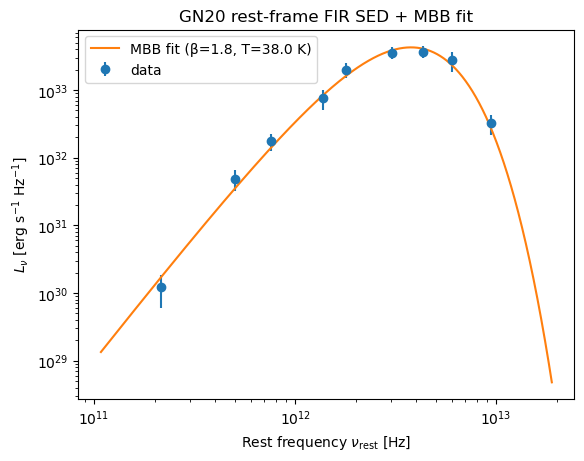

In [28]:
lam_peak_um = 2898.0 / T_best
print(f"Wien peak (blackbody) λ_peak ≈ {lam_peak_um:.1f} µm for T={T_best:.1f} K")

# Plot fit
nu_grid = np.logspace(np.log10(nu_rest.min()/2), np.log10(nu_rest.max()*2), 2000)
Lnu_model = A_best * shape_mbb(nu_grid, T_best)

plt.figure()
plt.errorbar(nu_rest, Lnu_rest, yerr=Lnu_err, fmt='o', label="data")
plt.plot(nu_grid, Lnu_model, label=f"MBB fit (β={beta}, T={T_best:.1f} K)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Rest frequency $\nu_{\rm rest}$ [Hz]")
plt.ylabel(r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]")
plt.title("GN20 rest-frame FIR SED + MBB fit")
plt.legend()
plt.show()

### Q3 — Dust mass Mdust using Eq. (17) at ν = 757 GHz

In [29]:
# Planck function B_nu(T) in cgs: erg s^-1 cm^-2 Hz^-1 sr^-1
def Bnu_cgs(nu, T):
    return (2*h*nu**3/c**2) / np.expm1(h*nu/(kB*T))

nu_eval = 757e9  # Hz
kappa0 = 1.3     # cm^2/g
nu0 = 666e9      # Hz

kappa_nu = kappa0 * (nu_eval/nu0)**beta

# Use best-fit model luminosity at nu=757 GHz
Lnu_eval = A_best * shape_mbb(nu_eval, T_best)

Mdust_g = Lnu_eval / (4*np.pi * kappa_nu * Bnu_cgs(nu_eval, T_best))
Msun_g = 1.92e33
Mdust_Msun = Mdust_g / Msun_g

print(f"kappa(757 GHz) = {kappa_nu:.3f} cm^2/g")
print(f"Lnu(757 GHz) model = {Lnu_eval:.3e} erg/s/Hz")
print(f"Mdust = {Mdust_Msun:.3e} Msun")

kappa(757 GHz) = 1.637 cm^2/g
Lnu(757 GHz) model = 1.393e+32 erg/s/Hz
Mdust = 8.833e+08 Msun


### Q4 — Gas-to-dust ratio δgd

In [30]:
# From Part III with alpha_CO=0.8 and your L'_CO = 1.293e11:
Lprime = 1.293e11
Mgas = 0.8 * Lprime  # Msun

delta_gd = Mgas / Mdust_Msun
print(f"Mgas (alpha_CO=0.8) = {Mgas:.3e} Msun")
print(f"delta_gd = Mgas/Mdust = {delta_gd:.1f}")

Mgas (alpha_CO=0.8) = 1.034e+11 Msun
delta_gd = Mgas/Mdust = 117.1


### Q5 — Total infrared luminosity LIR (8–1000 µm), Eq. (19)/(20)

In [47]:
lam1_um = 8.0
lam2_um = 1000.0

nu_max = c / (lam1_um * 1e-4)   # Hz
nu_min = c / (lam2_um * 1e-4)   # Hz

nu_int = np.logspace(np.log10(nu_min), np.log10(nu_max), 20000)
Lnu_int = A_best * shape_mbb(nu_int, T_best)


LIR = np.trapezoid(Lnu_int, nu_int)  # erg/s

Lsun = 3.82e33
LIR_Lsun = LIR / Lsun

print(f"LIR = {LIR:.3e} erg/s = {LIR_Lsun:.3e} Lsun")
LIR = np.trapezoid(Lnu_int, nu_int)  # erg/s


LIR = 1.915e+46 erg/s = 5.012e+12 Lsun


### Q6 — SFR from IR luminosity

In [ ]:
SFR_IR = 1.49e-10 * LIR_Lsun
print(f"SFR(IR) = {SFR_IR:.0f} Msun/yr")

SFR(IR) = 747 Msun/yr


# Bonus Part - Effect of the Cosmic Microwave Background on Dust Continuum Observations

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Constants (cgs)
# -----------------------------
c  = 2.99792458e10      # cm/s
h  = 6.62607004e-27     # erg*s
kB = 1.38064852e-16     # erg/K

# CMB temperature evolution
Tcmb0 = 2.73  # K
beta = 1.8    # as in Part IV / statement

def Bnu_cgs(nu, T):
    """Planck function B_nu in cgs: erg s^-1 cm^-2 Hz^-1 sr^-1"""
    return (2*h*nu**3/c**2) / np.expm1(h*nu/(kB*T))

def Tcmb(z):
    """TCMB(z) = TCMB,0 (1+z)"""
    return Tcmb0 * (1 + z)

# Eq. (23): dust temperature including CMB heating  :contentReference[oaicite:1]{index=1}
def Tdust_with_CMB(z, Tdust0, beta=beta):
    p = 4 + beta
    return (Tdust0**p + Tcmb0**p * ((1+z)**p - 1))**(1/p)

# Ratio of observed flux against CMB to intrinsic (Eq. 24 / Eq. 22) :contentReference[oaicite:2]{index=2}
# S_obs/S_intrinsic = [Bnu(Tdust(z)) - Bnu(Tcmb(z))] / Bnu(Tdust(z))
def contrast_fraction(nu_rest, z, Tdust0, beta=beta):
    Td_z = Tdust_with_CMB(z, Tdust0, beta=beta)
    Tc_z = Tcmb(z)
    return (Bnu_cgs(nu_rest, Td_z) - Bnu_cgs(nu_rest, Tc_z)) / Bnu_cgs(nu_rest, Td_z)

### Task - Plot TCMB(z) and Tdust(z) for several Tdust,0

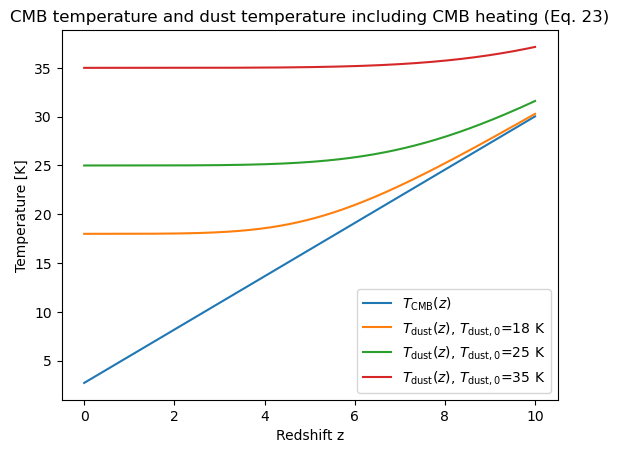

In [35]:
zgrid = np.linspace(0, 10, 400)

plt.figure()
plt.plot(zgrid, Tcmb(zgrid), label=r"$T_{\rm CMB}(z)$")

for Td0 in [18, 25, 35]:
    plt.plot(zgrid, Tdust_with_CMB(zgrid, Td0), label=rf"$T_{{\rm dust}}(z)$, $T_{{\rm dust,0}}$={Td0} K")

plt.xlabel("Redshift z")
plt.ylabel("Temperature [K]")
plt.title("CMB temperature and dust temperature including CMB heating (Eq. 23)")
plt.legend()
plt.show()

### Q1 - For which intrinsic dust temperatures is CMB heating non-negligible (for GN20 at z=4.05)?

In [36]:
z_gn20 = 4.05
for Td0 in [18, 25, 35, 38]:
    Td_z = Tdust_with_CMB(z_gn20, Td0)
    print(f"Tdust0={Td0:>2} K -> Tdust(z)={Td_z:.3f} K  (ΔT={Td_z-Td0:.3f} K)")

Tdust0=18 K -> Tdust(z)=18.609 K  (ΔT=0.609 K)
Tdust0=25 K -> Tdust(z)=25.135 K  (ΔT=0.135 K)
Tdust0=35 K -> Tdust(z)=35.027 K  (ΔT=0.027 K)
Tdust0=38 K -> Tdust(z)=38.018 K  (ΔT=0.018 K)


### Task - Flux contrast suppression at observed λobs = 3 mm

At z=4.05 and λobs=3 mm: S_obs/S_intrinsic = 0.814
Fraction missed = 0.186  (18.6%)


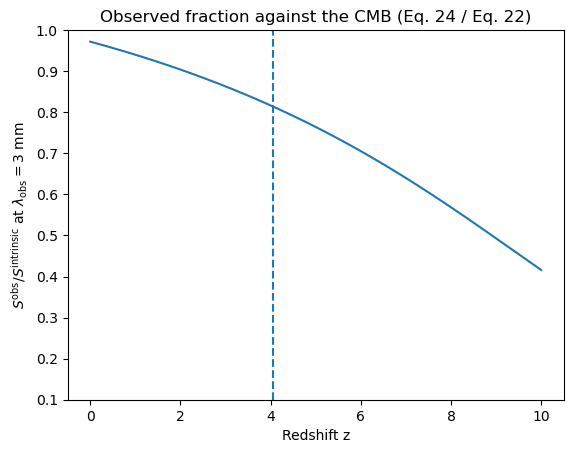

In [43]:
Tdust0_gn20 = 38.0   # from Part IV fit (ignoring CMB)

lam_obs_mm = 3.0
lam_obs_cm = lam_obs_mm * 0.1
nu_obs = c / lam_obs_cm
nu_rest = nu_obs * (1 + z_gn20)

frac_3mm = contrast_fraction(nu_rest, z_gn20, Tdust0_gn20)
print(f"At z=4.05 and λobs=3 mm: S_obs/S_intrinsic = {frac_3mm:.3f}")
print(f"Fraction missed = {1-frac_3mm:.3f}  ({(1-frac_3mm)*100:.1f}%)")


## Plot this fraction vs redshift
frac_vs_z = [contrast_fraction(nu_obs*(1+zz), zz, Tdust0_gn20) for zz in zgrid]

plt.figure()
plt.plot(zgrid, frac_vs_z)
plt.xlabel("Redshift z")
plt.ylabel(r"$S^{\rm obs}/S^{\rm intrinsic}$ at $\lambda_{\rm obs}=3$ mm")
plt.title("Observed fraction against the CMB (Eq. 24 / Eq. 22)")
plt.ylim(0.1, 1.0)
plt.axvline(4.05, linestyle='--')
plt.show()

### Task - Fit the dust SED including CMB contrast (Eq. 25)

In [41]:
from scipy.integrate import quad

# Load your Part IV rest-frame SED products (reuse the same transformations)
phot = np.loadtxt("../W9-The cold interstellar medium of galaxies/gn20phot.txt")
lam_obs_um = phot[:, 0]
S_mJy = phot[:, 1]
Serr_mJy = phot[:, 2]

DL_Mpc = 36375.56
Mpc_to_cm = 3.085677581e24
DL_cm = DL_Mpc * Mpc_to_cm

lam_obs_cm = lam_obs_um * 1e-4
nu_obs_arr = c / lam_obs_cm
nu_rest_arr = nu_obs_arr * (1 + z_gn20)

S_cgs = S_mJy * 1e-26
Serr_cgs = Serr_mJy * 1e-26

# Eq. (10): Lnu_rest = 4π DL^2/(1+z) Snu_obs  :contentReference[oaicite:8]{index=8}
Lnu = 4*np.pi * DL_cm**2 / (1+z_gn20) * S_cgs
Lnu_err = 4*np.pi * DL_cm**2 / (1+z_gn20) * Serr_cgs

# kappa law (same as Part IV)
kappa0 = 1.3    # cm^2/g
nu0 = 666e9     # Hz
Msun_g = 1.92e33

def kappa_nu(nu):
    return kappa0 * (nu/nu0)**beta

def best_Mdust_for_Td0(Td0):
    Td_z = Tdust_with_CMB(z_gn20, Td0)
    Tc_z = Tcmb(z_gn20)
    f = 4*np.pi * kappa_nu(nu_rest_arr) * (Bnu_cgs(nu_rest_arr, Td_z) - Bnu_cgs(nu_rest_arr, Tc_z))  # * Mdust_g -> Lnu
    w = 1.0 / (Lnu_err**2)
    Mdust_g = np.sum(w * f * Lnu) / np.sum(w * f * f)
    chi2 = np.sum(w * (Lnu - Mdust_g*f)**2)
    return Mdust_g, chi2, Td_z

Td0_grid = np.linspace(10, 120, 111)
out = np.array([best_Mdust_for_Td0(T) for T in Td0_grid], dtype=float)

Mdust_g_grid = out[:,0]
chi2_grid = out[:,1]
Td_z_grid = out[:,2]

i = np.argmin(chi2_grid)
Td0_best = Td0_grid[i]
Td_z_best = Td_z_grid[i]
Mdust_best = Mdust_g_grid[i] / Msun_g

# 1-sigma range on Td0 from Δχ²=1 (one scanned parameter)
chi2_min = chi2_grid[i]
mask = chi2_grid <= chi2_min + 1
Td0_lo, Td0_hi = Td0_grid[mask][0], Td0_grid[mask][-1]

print(f"Best-fit (with CMB):")
print(f"  Tdust,0 = {Td0_best:.1f} K  (≈ [{Td0_lo:.1f}, {Td0_hi:.1f}] K)")
print(f"  Tdust(z=4.05) = {Td_z_best:.3f} K")
print(f"  Mdust = {Mdust_best:.3e} Msun")

Best-fit (with CMB):
  Tdust,0 = 38.0 K  (≈ [36.0, 39.0] K)
  Tdust(z=4.05) = 38.018 K
  Mdust = 9.147e+08 Msun


### Q4 - Fraction of true flux missed (overall + where it matters)

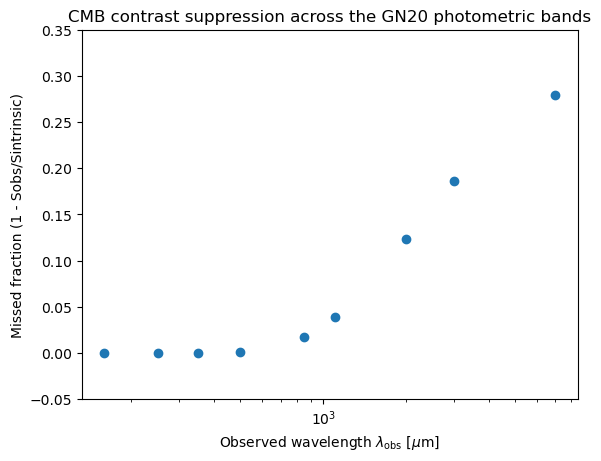

At λobs=3 mm: missed ≈ 18.6% (GN20, Tdust0~38 K)


In [46]:
frac_points = contrast_fraction(nu_rest_arr, z_gn20, Td0_best)
missed_points = 1 - frac_points

# Plot missed fraction vs observed wavelength
plt.figure()
plt.plot(lam_obs_um, missed_points, marker='o', linestyle='none')
plt.xscale("log")
plt.ylim(-0.05, 0.35)
plt.xlabel(r"Observed wavelength $\lambda_{\rm obs}$ [$\mu$m]")
plt.ylabel("Missed fraction (1 - Sobs/Sintrinsic)")
plt.title("CMB contrast suppression across the GN20 photometric bands")
plt.show()

print(f"At λobs=3 mm: missed ≈ {(1-frac_3mm)*100:.1f}% (GN20, Tdust0~38 K)")